---
authors:
  - name: Juniper Tyree
    orcid: 0000-0002-7923-9609
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: juntyr
  - name: Sami Sidoroff
    orcid: 0009-0007-1380-2554
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: Sidorow
---

# Random Projection

| [![version-badge]][version-url] | [![citation-badge]][citation-url] | [![source-badge]][source-url] | [![documentation-badge]][documentation-url] |
|:-:|:-:|:-:|:-:|

[version-badge]: https://img.shields.io/badge/v0.1.0a6-grey?style=for-the-badge
[citation-badge]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[source-badge]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[documentation-badge]: https://img.shields.io/badge/documentation-grey?style=for-the-badge&logo=readthedocs&logoColor=white

[version-url]: https://github.com/Sidorow/numcodecs-random-projection/tree/ce38aa7a585f7602bcf910c237b1feb6f9dbfd50
[citation-url]: https://doi.org/10.1016/j.imavis.2006.05.018
[source-url]: https://github.com/Sidorow/numcodecs-random-projection
[documentation-url]: https://numcodecs-random-projection.readthedocs.io/en/latest/

RPCodec (Random Projection Codec) is a lossy compressor for *n*-dimensional floating point data of arbitrary shape based on random projection, a dimensionality reduction technique grounded in the Johnson-Lindenstrauss lemma.

The compressor will automatically reshape non-2D data into a balanced 2D ($N \times D$) array for compression. Alternatively, the user can manually reshape the data to 2D a different way before and after compression.

**TODO: maybe mention this later**

RPCodec supports two projection methods: a Gaussian random projection, which constructs the projection matrix by sampling from a Gaussian distribution, and a DCT-based projection [^dct], which uses the Discrete Cosine Transform as a structured alternative. The DCT method is used by default. Both methods use a data-independent projection matrix, allowing individual samples to be compressed independently without a training phase. The data is standardized before projection for equal contribution of features and data drift mitigation.

RPCodec can target a user-specified mean absolute error (MAE), estimating the number of projected dimensions *k* required to approximately meet the error bound, though violations of the bound may occur. Alternatively, a fixed compression ratio can be specified directly. It is worth mentioning however, that the theoretical properties of the Johnson-Lindenstrauss lemma guarantee pairwise distance preservation rather than pointwise errors.

[^dct]: Amador, J. J. (2006). Random projection and orthonormality for lossy image compression. *Image and Vision Computing*, 25(5), 754–766. Available from: [doi:10.1016/j.imavis.2006.05.018](https://doi.org/10.1016/j.imavis.2006.05.018).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

## Importing the `RPCodec` compressor

In [5]:
from numcodecs_random_projection import RPCodec

In [6]:
?RPCodec

Init signature:
RPCodec(
    mae: None | float = None,
    cr: None | float = None,
    k: None | int = None,
    method: str | numcodecs_random_projection.RPMethod = <RPMethod.dct: 'dct'>,
    seed: None | int = None,
    max_block_memory: None | int = None,
    debug: bool = False,
) -> None
Docstring:     
Random projection codec for lossy compression of numerical data.

Compresses 2D finite floating point data by projecting it onto a
lower-dimensional subspace using a specified method. The Discrete Cosine
Transform (DCT) is used by default.

A two-dimensional array of shape N x D is encoded as an array of
shape N x K, where `k` is either set explicitly or chosen based on the
compression ratio `cr`. Alternatively, `k` can be estimated from the data
during encoding by giving a loose Mean Absolute Error (MAE) bound.

Arrays that are not two-dimensional are automatically reshaped to be 2D as
follows:
- 0D scalar -> 1x1
- 1D array of shape D -> 1xD
- 2D array of shape NxD -> NxD
- >2D a

## Targeting a specific compression ratio

RPCodec can target a specific compression ratio using:

In [7]:
cr = 10  # 10x compression

RPCodec(cr=cr)  # DCT method used by default

RPCodec(cr=10, method='dct', debug=False)

Or a specific reduced dimension $k$, assuming the number of dimensions $D$ is known, using:

In [8]:
k = 415296  # 10% of total test data size

RPCodec(k=k)

RPCodec(k=415296, method='dct', debug=False)

## Bounding the mean absolute error

RPCodec can loosely bound the mean absolute error based on the feature dimension $D$ using:

In [9]:
mae = 0.1  # target MAE in data units

RPCodec(mae=mae)

RPCodec(mae=0.1, method='dct', debug=False)

## Handling of NaN Missing Values

NaN values are automatically replaced with zeros before compression but are not restored during decompression.

**TODO: mention meta-compressor**

**TODO: add PCA examples**

## Example

In [10]:
# Load the data
ds = open_remote_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="h5netcdf",
    decode_timedelta=True,
)
da = ds["2t"]

In [11]:
mae = 0.1  # target MAE in standardized data units

codec_dct = RPCodec(method="dct", mae=mae)

# set random seed for reproducibility
codec_gauss = RPCodec(method="gaussian", mae=mae, seed=42)

In [12]:
# encode and decode the data using both methods
da_enc_dct = codec_dct.encode(da.values)
da_dec_dct = da.copy(data=codec_dct.decode(da_enc_dct))

da_enc_gauss = codec_gauss.encode(da.values)
da_dec_gauss = da.copy(data=codec_gauss.decode(da_enc_gauss))

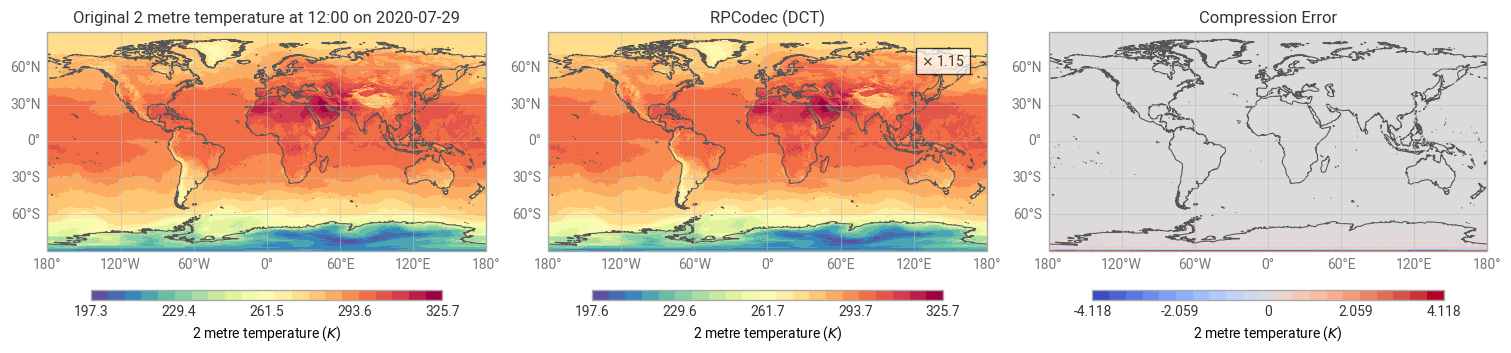

In [13]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec_dct,
    fig.add_map(0, 1),
    title="RPCodec (DCT)",
    cr=da.nbytes / np.array(da_enc_dct).nbytes,
)
quickplot(da_dec_dct - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()

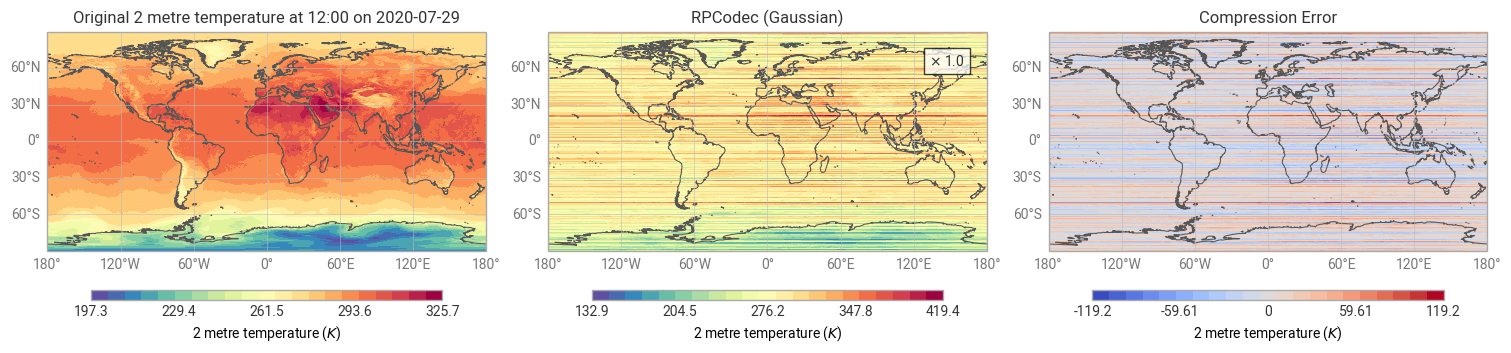

In [14]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec_gauss,
    fig.add_map(0, 1),
    title="RPCodec (Gaussian)",
    cr=da.nbytes / np.array(da_enc_gauss).nbytes,
)
quickplot(da_dec_gauss - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()